# Recitation: Linear Regression & Feature Engineering
- Simple, Multiple and Polynomial Linear Regression
- Interpretation of Intercepts and Slopes
- Why intercepts can be negative and how to fix them
- Log-transforming the outcome when heteroskedasticity is present
- Handling Categorical Variables:
  - Label Encoding
  - One-Hot Encoding
  - Dummy Variable Trap
- Normalization and Scaling of Features


In [1]:
# Basic Imports for the Entire Notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split

# Set a consistent style for plots
sns.set(style="whitegrid")


## 2. Simple Linear Regression

Linear regression is one of the simplest and most interpretable machine learning models. In its basic form, it models the relationship between a single independent variable (feature) and a dependent variable (target) as a straight line:

$$
y = \beta_0 + \beta_1 x
$$

- $\beta_0$ is the **intercept** (value of $y$ when $x = 0$)
- $\beta_1$ is the **slope** (how much $y$ changes for each unit increase in $x$)

We'll generate synthetic data and fit a linear model using `scikit-learn`.


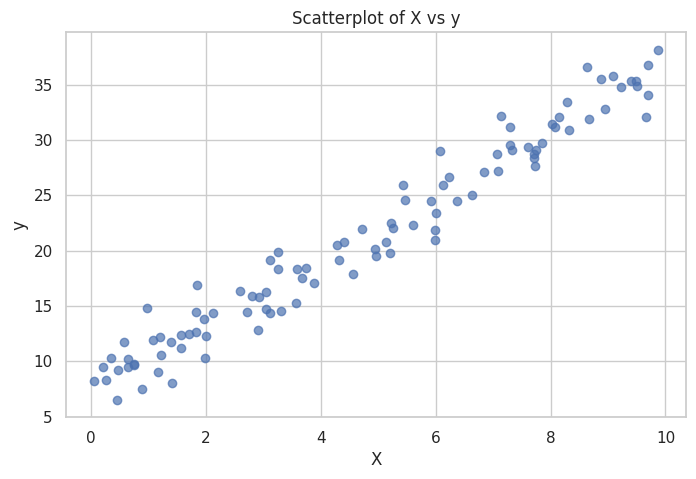

In [2]:
# Generate simple linear data
np.random.seed(42)
n_samples = 100
X = np.random.rand(n_samples, 1) * 10  # Feature between 0 and 10
y = 3 * X.squeeze() + 7 + np.random.randn(n_samples) * 2  # y = 3x + 7 + noise

# Visualize data
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.7)
plt.title("Scatterplot of X vs y")
plt.xlabel("X")
plt.ylabel("y")
plt.show()


In [3]:
# Fit simple linear regression model
model = LinearRegression()
model.fit(X, y)

# Model coefficients
print(f"Intercept (β₀): {model.intercept_:.2f}")
print(f"Slope (β₁): {model.coef_[0]:.2f}")


Intercept (β₀): 7.43
Slope (β₁): 2.91


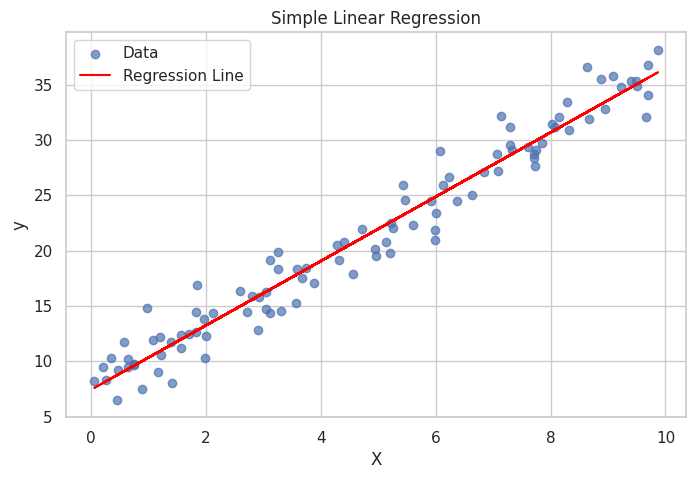

In [4]:
# Plot regression line
y_pred = model.predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.7, label="Data")
plt.plot(X, y_pred, color="red", label="Regression Line")
plt.title("Simple Linear Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


## 3. Multiple Linear Regression

In multiple linear regression, we extend the simple linear model to include two or more independent variables:

$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n
$$

Each coefficient $\beta_i$ represents the change in $y$ for a one-unit change in $x_i$, holding all other variables constant.

We'll generate a dataset with two features and fit a multiple linear regression model to it.


In [5]:
# Generate synthetic data with two features
np.random.seed(0)
n_samples = 100
X1 = np.random.rand(n_samples, 1) * 10
X2 = np.random.rand(n_samples, 1) * 5
X_multi = np.hstack([X1, X2])

# Generate target variable with some noise
y_multi = 2 * X1.squeeze() + 4 * X2.squeeze() + 5 + np.random.randn(n_samples) * 2

# Convert to DataFrame for readability
df_multi = pd.DataFrame({
    'X1': X1.squeeze(),
    'X2': X2.squeeze(),
    'y': y_multi
})
df_multi.head()


,X1,X2,y
0,5.488135,3.389083,31.785873
1,7.151894,1.350040,22.544084
2,6.027634,3.675970,29.464211
3,5.448832,4.810943,34.265794
4,4.236548,1.243766,17.452094


In [6]:
# Fit multiple linear regression model
model_multi = LinearRegression()
model_multi.fit(X_multi, y_multi)

# Coefficients
print(f"Intercept (β₀): {model_multi.intercept_:.2f}")
print(f"Coefficient for X1 (β₁): {model_multi.coef_[0]:.2f}")
print(f"Coefficient for X2 (β₂): {model_multi.coef_[1]:.2f}")


Intercept (β₀): 5.61
Coefficient for X1 (β₁): 1.89
Coefficient for X2 (β₂): 3.90


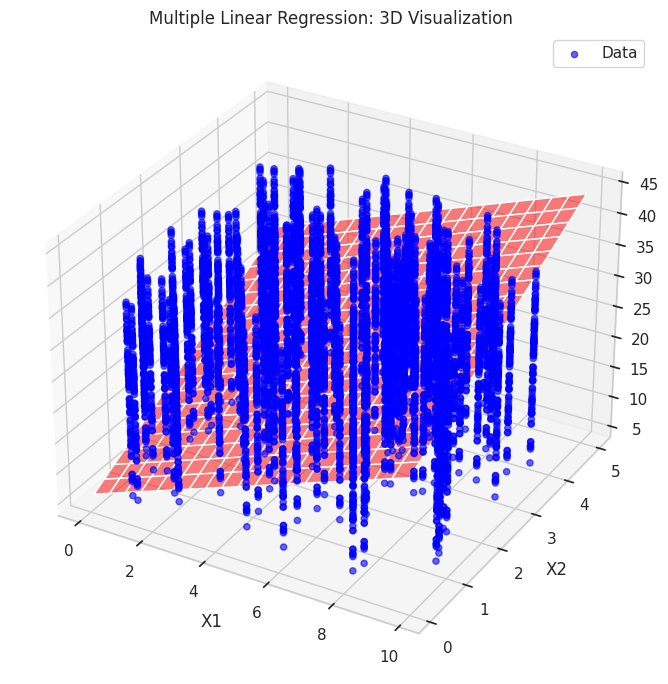

In [7]:
from mpl_toolkits.mplot3d import Axes3D

# Prepare a meshgrid for the plane
x1_range = np.linspace(X1.min(), X1.max(), 20)
x2_range = np.linspace(X2.min(), X2.max(), 20)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)

# Predict y values over the grid
y_pred_grid = (
    model_multi.intercept_
    + model_multi.coef_[0] * x1_grid
    + model_multi.coef_[1] * x2_grid
)

# Plotting the 3D scatter and plane
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of actual data
ax.scatter(X1, X2, y_multi, c='blue', alpha=0.6, label='Data')

# Regression plane
ax.plot_surface(x1_grid, x2_grid, y_pred_grid, color='red', alpha=0.5)

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')
ax.set_title('Multiple Linear Regression: 3D Visualization')
plt.legend()
plt.tight_layout()
plt.show()


## 4. Polynomial Regression

Polynomial regression is a form of regression analysis in which the relationship between the independent variable $x$ and the dependent variable $y$ is modelled as an $n$th degree polynomial in $x$.

$$y = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + \dots + \beta_n x^n + \epsilon$$

Although polynomial regression fits a nonlinear model to the data, as a statistical estimation problem it is linear, in the sense that the regression function $E(y | x)$ is linear in the unknown parameters that are estimated from the data. For this reason, polynomial regression is considered to be a special case of multiple linear regression.

We use `PolynomialFeatures` from `sklearn.preprocessing` to transform our features.

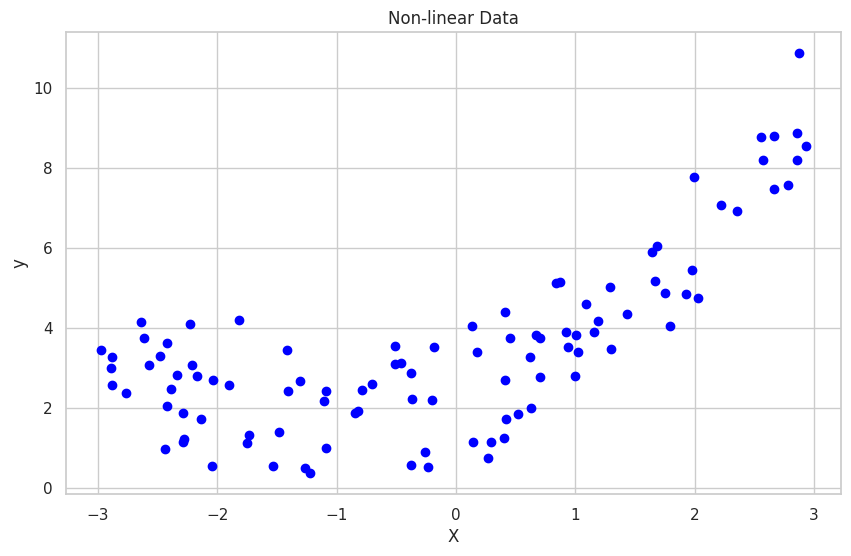

In [8]:
from sklearn.preprocessing import PolynomialFeatures

# Generate non-linear data
np.random.seed(0)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue')
plt.title('Non-linear Data')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

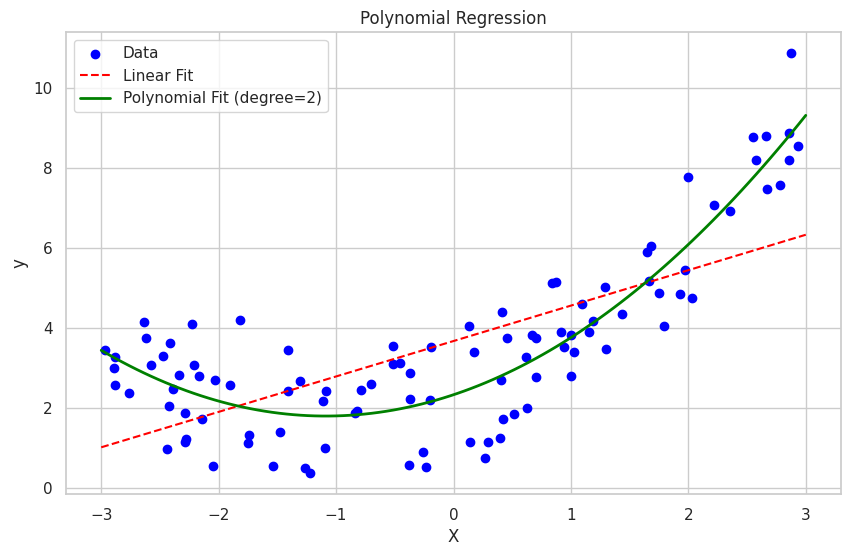

Intercept: 2.34
Coefficients: [0.97906552 0.44978823]


In [9]:
# 1. Linear Regression (Underfitting)
lin_reg = LinearRegression()
lin_reg.fit(X, y)

# 2. Polynomial Regression
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

lin_reg_poly = LinearRegression()
lin_reg_poly.fit(X_poly, y)

# Visualization
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg_poly.predict(X_new_poly)
y_lin_pred = lin_reg.predict(X_new)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Data')
plt.plot(X_new, y_lin_pred, color='red', linestyle='--', label='Linear Fit')
plt.plot(X_new, y_new, color='green', linewidth=2, label='Polynomial Fit (degree=2)')
plt.title('Polynomial Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

print(f"Intercept: {lin_reg_poly.intercept_[0]:.2f}")
print(f"Coefficients: {lin_reg_poly.coef_[0]}")

## 5. Interpreting Intercepts and Slopes

Understanding the meaning of coefficients in a linear regression model is essential for interpretation.

- **Intercept ($\beta_0$)**: The predicted value of $y$ when all input features are 0.
- **Slope ($\beta_i$)**: The expected change in $y$ when $x_i$ increases by 1 unit, holding other variables constant.

### When the Intercept Doesn't Make Sense

Sometimes the intercept doesn't make practical sense. For example, if a variable like height (in cm) is used in the model, an input value of 0 cm is not meaningful in reality. However, the model still computes an intercept because it's part of the linear equation.

Let’s see an example.


In [10]:
# Generate a dataset where zero values are not meaningful
np.random.seed(1)
height = np.random.uniform(140, 200, 100)  # height in cm
weight = 0.4 * height + 10 + np.random.randn(100) * 5  # weight in kg

df_hw = pd.DataFrame({'Height': height, 'Weight': weight})

# Fit linear regression model
model_hw = LinearRegression()
model_hw.fit(df_hw[['Height']], df_hw['Weight'])

intercept = model_hw.intercept_
slope = model_hw.coef_[0]

print(f"Intercept (β₀): {intercept:.2f}")
print(f"Slope (β₁): {slope:.2f}")


Intercept (β₀): 14.86
Slope (β₁): 0.37


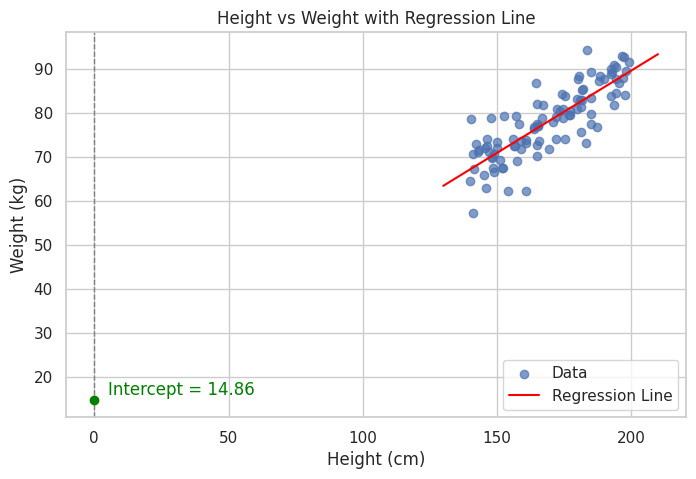

In [11]:
# Plot the data and regression line
plt.figure(figsize=(8, 5))
plt.scatter(df_hw['Height'], df_hw['Weight'], alpha=0.7, label='Data')
x_vals = np.array([130, 210])
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, color='red', label='Regression Line')

# Annotate intercept
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.scatter(0, intercept, color='green', zorder=5)
plt.text(5, intercept + 1, f'Intercept = {intercept:.2f}', color='green')

plt.title("Height vs Weight with Regression Line")
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.legend()
plt.grid(True)
plt.show()


In this case, the intercept represents the predicted weight of a person who is 0 cm tall, which is clearly nonsensical. This is a common issue when the value 0 is outside the range of meaningful input data.

A common solution is **centering** the input feature around its mean, which we’ll do in the next section.


## 5. Feature Centering to Fix Interpretation

When the value 0 is not meaningful for a feature, the intercept of a linear model becomes difficult to interpret. A common fix is to **center** the feature — subtract the mean so that the average value becomes 0.

This way, the intercept represents the predicted value of $y$ when the feature is at its average value, which is usually much more interpretable.

Mathematically:

$$
x_{\text{centered}} = x - \bar{x}
$$

Let’s apply this idea to the height/weight example.


In [12]:
# Center the height feature
df_hw['Height_centered'] = df_hw['Height'] - df_hw['Height'].mean()

# Fit linear model with centered feature
model_centered = LinearRegression()
model_centered.fit(df_hw[['Height_centered']], df_hw['Weight'])

intercept_c = model_centered.intercept_
slope_c = model_centered.coef_[0]

print(f"Intercept (β₀): {intercept_c:.2f}")
print(f"Slope (β₁): {slope_c:.2f}")


Intercept (β₀): 78.08
Slope (β₁): 0.37


Now, the intercept corresponds to the predicted weight at the **average height**, which is much more interpretable.


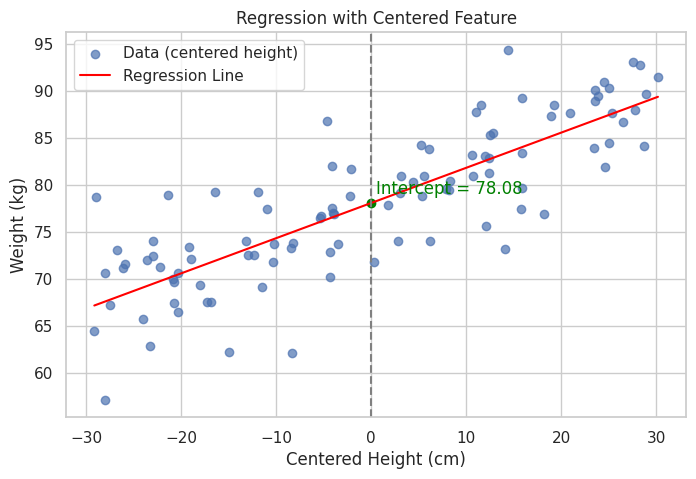

In [13]:
# Plot the data with centered feature
plt.figure(figsize=(8, 5))
plt.scatter(df_hw['Height_centered'], df_hw['Weight'], alpha=0.7, label='Data (centered height)')

x_vals_c = np.linspace(df_hw['Height_centered'].min(), df_hw['Height_centered'].max(), 100)
y_vals_c = intercept_c + slope_c * x_vals_c

plt.plot(x_vals_c, y_vals_c, color='red', label='Regression Line')
plt.axvline(0, color='gray', linestyle='--')
plt.scatter(0, intercept_c, color='green')
plt.text(0.5, intercept_c + 1, f'Intercept = {intercept_c:.2f}', color='green')

plt.title("Regression with Centered Feature")
plt.xlabel("Centered Height (cm)")
plt.ylabel("Weight (kg)")
plt.legend()
plt.grid(True)
plt.show()


## 6. Log-Transforming the Outcome (for Heteroskedasticity)

### What is Heteroskedasticity?

Heteroskedasticity occurs when the variance of the residuals (errors) is not constant across all levels of the input feature(s). In other words, the spread of the data increases or decreases with the feature values, violating a key assumption of linear regression.

This can often be corrected by applying a **logarithmic transformation** to the target variable.

Let’s simulate a dataset with clear heteroskedasticity and see how a log transformation can help.


In [14]:
# Simulate heteroskedastic data
np.random.seed(42)
x_het = np.random.rand(200) * 10
noise = np.random.randn(200) * (x_het)  # increasing noise
y_het = 2 * x_het + 5 + noise

df_het = pd.DataFrame({'x': x_het, 'y': y_het})


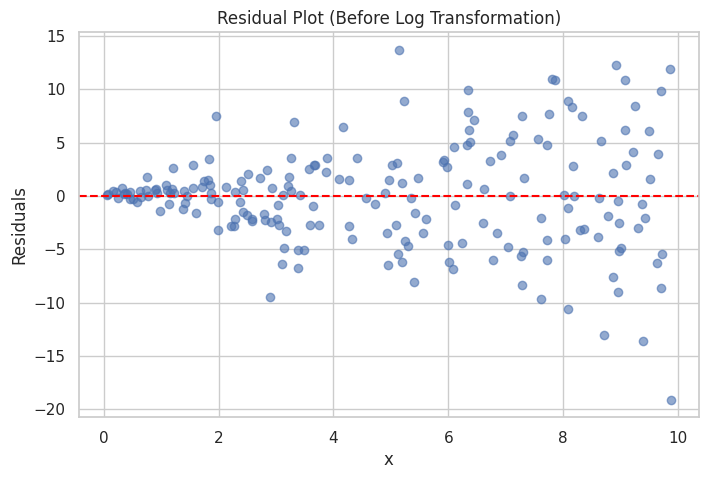

In [15]:
# Visualize original data and residuals
model_het = LinearRegression()
model_het.fit(df_het[['x']], df_het['y'])
y_pred_het = model_het.predict(df_het[['x']])

residuals = df_het['y'] - y_pred_het

plt.figure(figsize=(8, 5))
plt.scatter(df_het['x'], residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot (Before Log Transformation)")
plt.xlabel("x")
plt.ylabel("Residuals")
plt.grid(True)
plt.show()


As you can see, the residuals fan out as `x` increases — this is a classic sign of heteroskedasticity.

We'll now apply a log transformation to the target variable `y` and re-fit the model.


In [16]:
# Apply log transformation to y
df_het['log_y'] = np.log(df_het['y'])

# Fit model on log-transformed target
model_log = LinearRegression()
model_log.fit(df_het[['x']], df_het['log_y'])

log_y_pred = model_log.predict(df_het[['x']])
log_residuals = df_het['log_y'] - log_y_pred


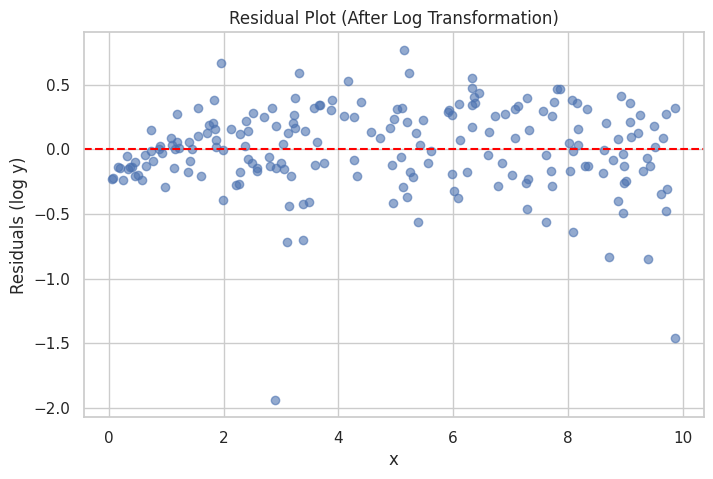

In [17]:
# Visualize residuals after log transformation
plt.figure(figsize=(8, 5))
plt.scatter(df_het['x'], log_residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot (After Log Transformation)")
plt.xlabel("x")
plt.ylabel("Residuals (log y)")
plt.grid(True)
plt.show()


After the log transformation, the residuals are more evenly distributed across `x`. This transformation helps meet the assumptions of linear regression and often improves model performance when dealing with non-constant variance in the response variable.


## 7. Categorical Variables (Encoding Methods)

Many datasets contain **categorical features** — variables that represent categories rather than continuous quantities (e.g., "City", "Color", "Product Type").

Linear models can't directly handle these non-numeric features, so we must convert them into numerical form. The most common encoding techniques are:

1. **Label Encoding**
2. **One-Hot Encoding**
3. **Dummy Variables (One-Hot Encoding with one column dropped)**

We will walk through each of these using a toy dataset.


In [18]:
# Create a toy dataset
df_cat = pd.DataFrame({
    'City': ['Paris', 'Berlin', 'Paris', 'London', 'Berlin', 'London', 'Paris'],
    'Sales': [200, 150, 220, 130, 170, 160, 210]
})

df_cat


,City,Sales
0,Paris,200
1,Berlin,150
2,Paris,220
3,London,130
4,Berlin,170
5,London,160
6,Paris,210


### 7.1 Label Encoding

Label encoding assigns a unique integer to each category. While it's simple, it introduces an **artificial ordering**, which may be misleading for linear models.


In [19]:
le = LabelEncoder()
df_cat['City_LabelEncoded'] = le.fit_transform(df_cat['City'])

df_cat[['City', 'City_LabelEncoded']]


,City,City_LabelEncoded
0,Paris,2
1,Berlin,0
2,Paris,2
3,London,1
4,Berlin,0
5,London,1
6,Paris,2


In [20]:
# Label encoding with meaningful order: Education levels
df_edu = pd.DataFrame({
    'Education': ['High School', 'Bachelor’s', 'Master’s', 'PhD', 'Bachelor’s', 'PhD']
})

# Manually define correct order
edu_order = ['High School', 'Bachelor’s', 'Master’s', 'PhD']
df_edu['Education'] = pd.Categorical(df_edu['Education'], categories=edu_order, ordered=True)

# Encode as ordered labels
df_edu['Education_LabelEncoded'] = df_edu['Education'].cat.codes

df_edu


,Education,Education_LabelEncoded
0,High School,0
1,Bachelor’s,1
2,Master’s,2
3,PhD,3
4,Bachelor’s,1
5,PhD,3


As you can see, the cities are now represented as integers. However, the model may wrongly assume "Berlin" < "London" < "Paris", which implies an ordering that doesn't exist.

### 7.2 One-Hot Encoding

One-hot encoding creates a new binary (0/1) column for each category.


In [21]:
# Apply one-hot encoding
df_onehot = pd.get_dummies(df_cat[['City']], prefix='City')
df_encoded = pd.concat([df_cat, df_onehot], axis=1)

df_encoded


,City,Sales,City_LabelEncoded,City_Berlin,City_London,City_Paris
0,Paris,200,2,False,False,True
1,Berlin,150,0,True,False,False
2,Paris,220,2,False,False,True
3,London,130,1,False,True,False
4,Berlin,170,0,True,False,False
5,London,160,1,False,True,False
6,Paris,210,2,False,False,True


Each city now has its own binary column. This solves the problem of implicit ordering.

### 7.3 Dummy Variable Trap

If we include all one-hot encoded columns in a linear regression model along with an intercept, we introduce **perfect multicollinearity**. This is known as the **dummy variable trap**.

To avoid it, we drop one of the categories (it becomes the reference group).


In [22]:
# Drop one category to avoid dummy variable trap
df_encoded = pd.get_dummies(df_cat[['City']], prefix='City', drop_first=True)
df_final = pd.concat([df_cat['Sales'], df_encoded], axis=1)

df_final


,Sales,City_London,City_Paris
0,200,False,True
1,150,False,False
2,220,False,True
3,130,True,False
4,170,False,False
5,160,True,False
6,210,False,True


Now we’ve encoded the categorical variable correctly for linear regression. The dropped category ("Berlin", in this case) becomes the baseline. The coefficients for the remaining categories will be interpreted relative to that baseline.

We'll use these encoded variables in a regression model later in this notebook.


## Summary: Encoding Methods for Categorical Variables

Here’s a quick comparison of the main encoding techniques:

### Label Encoding

| Aspect               | Description                                                                 |
|----------------------|-----------------------------------------------------------------------------|
| **How it works**     | Assigns a unique integer to each category                                  |
| **Advantages**       | Simple, minimal memory usage                                                |
| **Disadvantages**    | Implies an ordinal relationship that may not exist                         |
| **When to Use**      | When categories have a clear order (e.g., low, medium, high)                |
| **When Not to Use**  | When categories are nominal with no order (e.g., city names, colors)        |

---

### One-Hot Encoding

| Aspect               | Description                                                                 |
|----------------------|-----------------------------------------------------------------------------|
| **How it works**     | Creates a separate binary column for each category                         |
| **Advantages**       | No artificial ordering; interpretable coefficients                         |
| **Disadvantages**    | Increases dimensionality; can be inefficient with many categories           |
| **When to Use**      | For nominal categorical variables with a small to moderate number of levels |
| **When Not to Use**  | When there are too many unique categories (e.g., thousands of zip codes)    |

---

### Dummy Variable Encoding

| Aspect               | Description                                                                 |
|----------------------|-----------------------------------------------------------------------------|
| **How it works**     | Like one-hot encoding, but drops one category to avoid multicollinearity   |
| **Advantages**       | Avoids dummy variable trap; interpretable in models with intercept          |
| **Disadvantages**    | Still increases dimensionality                                              |
| **When to Use**      | When using linear models that include an intercept                         |
| **When Not to Use**  | Same as one-hot; problematic if too many categories                         |


## 8. Normalization & Scaling of Features

Many machine learning models are sensitive to the **scale** of input features. This includes:

- Models using gradient descent (e.g., linear regression, logistic regression, neural networks)
- Distance-based models (e.g., k-NN, SVM)

### Why Scale?

If one feature ranges from 0–1000 and another from 0–1, the model may treat the larger-scaled feature as more important, even if it's not.

Two common scaling techniques are:

1. **Min-Max Scaling** (Normalization)
2. **Standardization** (Z-score Scaling)


In [23]:
# Simulate a dataset with different feature scales
np.random.seed(42)
df_scale = pd.DataFrame({
    'Age': np.random.randint(18, 65, size=100),
    'Income': np.random.randint(20000, 100000, size=100)
})

df_scale.describe()


,Age,Income
count,100.00000,100.000000
mean,40.88000,60243.000000
std,13.99082,23009.842232
min,18.00000,20206.000000
25%,30.50000,42218.250000
50%,41.00000,62749.000000
75%,53.25000,81158.500000
max,64.00000,99575.000000


### 8.1 Min-Max Scaling

Rescales features to a fixed range, typically [0, 1].

Formula:

$$
x' = \frac{x - \min(x)}{\max(x) - \min(x)}
$$


In [24]:
scaler_minmax = MinMaxScaler()
df_minmax = pd.DataFrame(scaler_minmax.fit_transform(df_scale), columns=df_scale.columns)

df_minmax.describe()


,Age,Income
count,100.000000,100.000000
mean,0.497391,0.504441
std,0.304148,0.289910
min,0.000000,0.000000
25%,0.271739,0.277341
50%,0.500000,0.536015
75%,0.766304,0.767964
max,1.000000,1.000000


### 8.2 Standardization (Z-score Scaling)

Centers features around mean 0 with standard deviation 1.

Formula:

$$
x' = \frac{x - \mu}{\sigma}
$$


In [25]:
scaler_standard = StandardScaler()
df_standard = pd.DataFrame(scaler_standard.fit_transform(df_scale), columns=df_scale.columns)

df_standard.describe()


,Age,Income
count,1.000000e+02,1.000000e+02
mean,-1.998401e-16,-3.608225e-18
std,1.005038e+00,1.005038e+00
min,-1.643597e+00,-1.748760e+00
25%,-7.456527e-01,-7.872959e-01
50%,8.620263e-03,1.094586e-01
75%,8.886054e-01,9.135599e-01
max,1.660837e+00,1.717967e+00


## Summary: When to Use Which Scaling Method

| Method             | Output Range     | Sensitive to Outliers | Preserves Shape | Use Case                                 |
|--------------------|------------------|------------------------|------------------|-------------------------------------------|
| Min-Max Scaling    | [0, 1]           | Yes                    | Yes              | Neural nets, models needing bounded input |
| Standardization    | Mean 0, SD 1     | Less                   | Yes              | Most ML models, especially linear models  |

You usually don’t need to scale features for tree-based models (e.g., decision trees, random forests), but scaling is critical for regression, distance-based methods, and deep learning.
